In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

df = pd.read_csv("/Users/ahmednuur/Downloads/stock_market.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2014-01-02,3.20,3.25,3.19,3.24,13127000
1,2014-01-03,3.21,3.22,3.20,3.21,4642000
2,2014-01-06,3.23,3.27,3.22,3.23,11781500
3,2014-01-07,3.23,3.25,3.21,3.24,17191500
4,2014-01-08,3.41,3.42,3.22,3.25,42864500


In [3]:
df.shape

(3179, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3179 entries, 0 to 3178
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3179 non-null   object 
 1   Close   3179 non-null   float64
 2   High    3179 non-null   float64
 3   Low     3179 non-null   float64
 4   Open    3179 non-null   float64
 5   Volume  3179 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 149.1+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Close,"3,179.00",13.37,7.10,2.85,6.22,13.06,19.00,30.26
High,"3,179.00",13.47,7.15,2.93,6.25,13.10,19.12,30.34
Low,"3,179.00",13.27,7.05,2.84,6.19,12.92,18.89,30.03
Open,"3,179.00",13.37,7.10,2.85,6.22,13.00,19.00,30.25
Volume,"3,179.00","5,846,251.24","4,516,048.42","941,000.00","3,240,200.00","4,549,500.00","6,827,350.00","78,397,000.00"


In [6]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Close,High,Low,Open,Volume
0,2014-01-02,3.20,3.25,3.19,3.24,13127000
1,2014-01-03,3.21,3.22,3.20,3.21,4642000
2,2014-01-06,3.23,3.27,3.22,3.23,11781500
3,2014-01-07,3.23,3.25,3.21,3.24,17191500
4,2014-01-08,3.41,3.42,3.22,3.25,42864500


In [9]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Start Date:", df["Date"].min().date())
print("End Date:", df["Date"].max().date())
print("Trading Days:", df["Date"].nunique())

Rows: 3179
Columns: 6
Start Date: 2014-01-02
End Date: 2026-08-24
Trading Days: 3179


In [10]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)
df["DayOfWeek"] = df["Date"].dt.day_name()

In [11]:
df["Daily_Return"] = df["Close"].pct_change() * 100

df["Price_Change"] = df["Close"].diff()

df["Price_Change_Percent"] = (
    df["Close"].pct_change() * 100
)

df["Daily_Range"] = df["High"] - df["Low"]

df["Open_Close_Difference"] = (
    df["Close"] - df["Open"]
)

df["High_Low_Percentage"] = (
    (df["High"] - df["Low"]) / df["Low"]
) * 100

df.head()

,Date,Close,High,Low,Open,Volume,Year,Month,MonthName,Quarter,YearMonth,DayOfWeek,Daily_Return,Price_Change,Price_Change_Percent,Daily_Range,Open_Close_Difference,High_Low_Percentage
0,2014-01-02,3.20,3.25,3.19,3.24,13127000,2014,1,January,1,2014-01,Thursday,NaN,NaN,NaN,0.06,-0.03,1.81
1,2014-01-03,3.21,3.22,3.20,3.21,4642000,2014,1,January,1,2014-01,Friday,0.12,0.00,0.12,0.03,-0.01,0.82
2,2014-01-06,3.23,3.27,3.22,3.23,11781500,2014,1,January,1,2014-01,Monday,0.70,0.02,0.70,0.04,0.00,1.27
3,2014-01-07,3.23,3.25,3.21,3.24,17191500,2014,1,January,1,2014-01,Tuesday,0.12,0.00,0.12,0.03,-0.01,1.05
4,2014-01-08,3.41,3.42,3.22,3.25,42864500,2014,1,January,1,2014-01,Wednesday,5.37,0.17,5.37,0.20,0.16,6.14


In [12]:
print("Highest Price:", f"{df['High'].max():,.2f}")
print("Lowest Price:", f"{df['Low'].min():,.2f}")
print("Highest Close:", f"{df['Close'].max():,.2f}")
print("Lowest Close:", f"{df['Close'].min():,.2f}")
print("Average Close:", f"{df['Close'].mean():,.2f}")
print("Average Volume:", f"{df['Volume'].mean():,.0f}")

Highest Price: 30.34
Lowest Price: 2.84
Highest Close: 30.26
Lowest Close: 2.85
Average Close: 13.37
Average Volume: 5,846,251


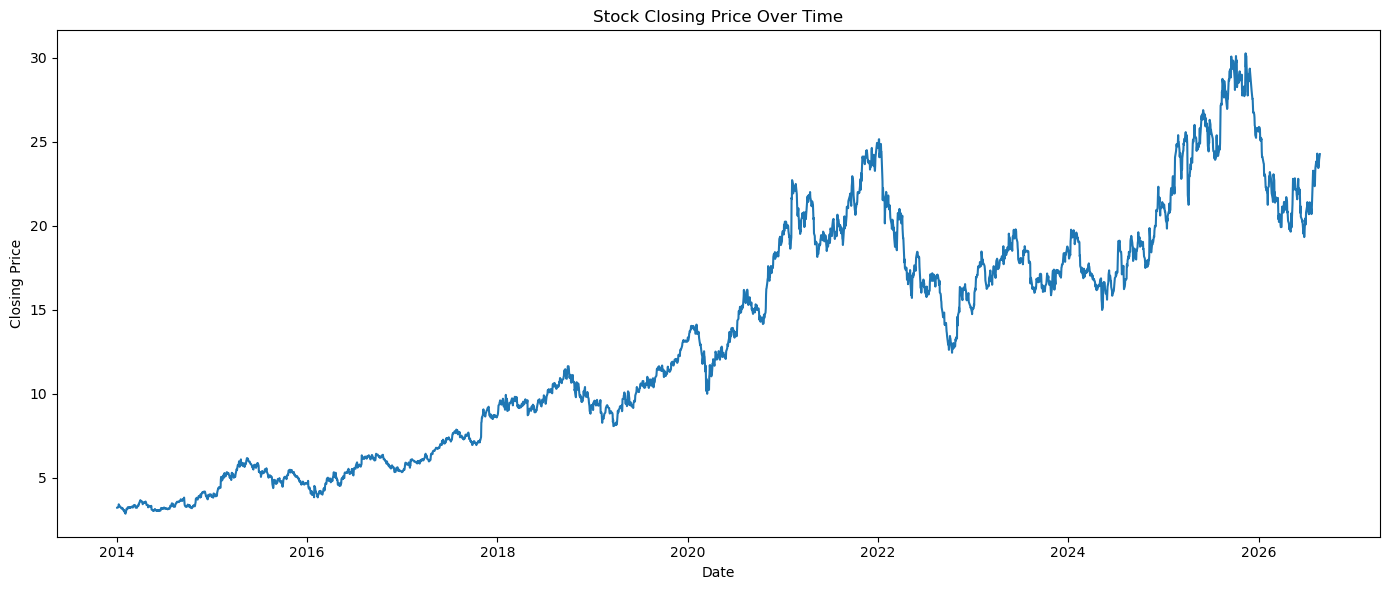

In [13]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Close"
)

plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()

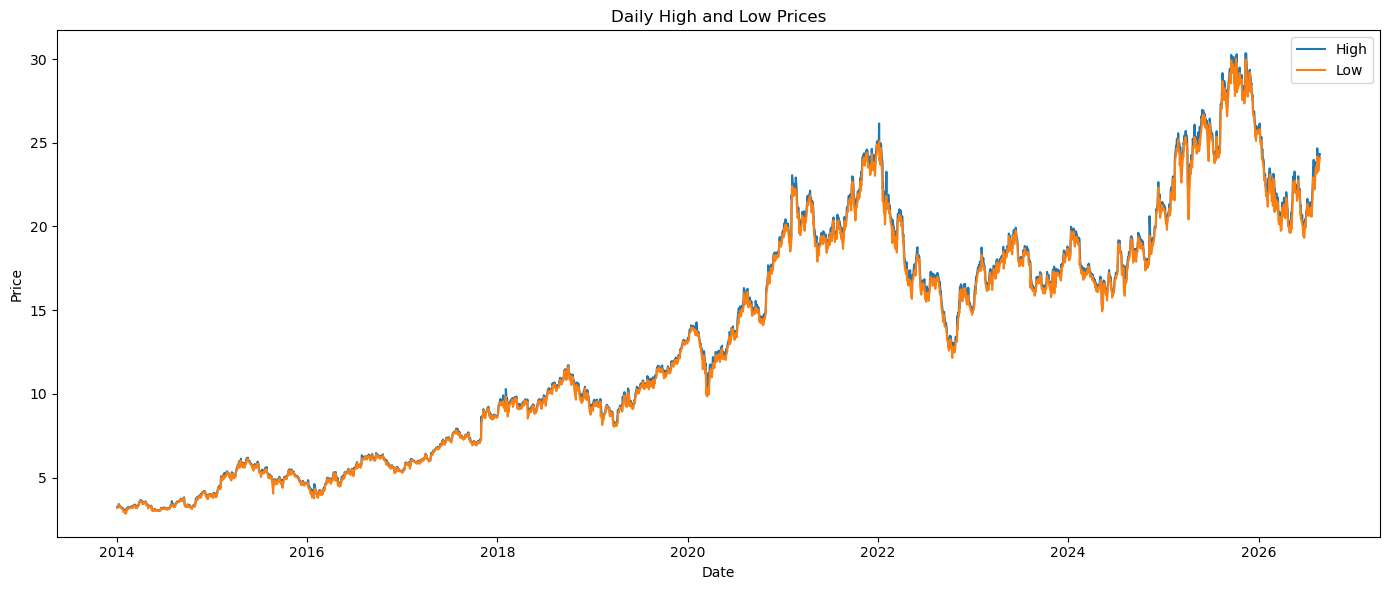

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")

plt.title("Daily High and Low Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

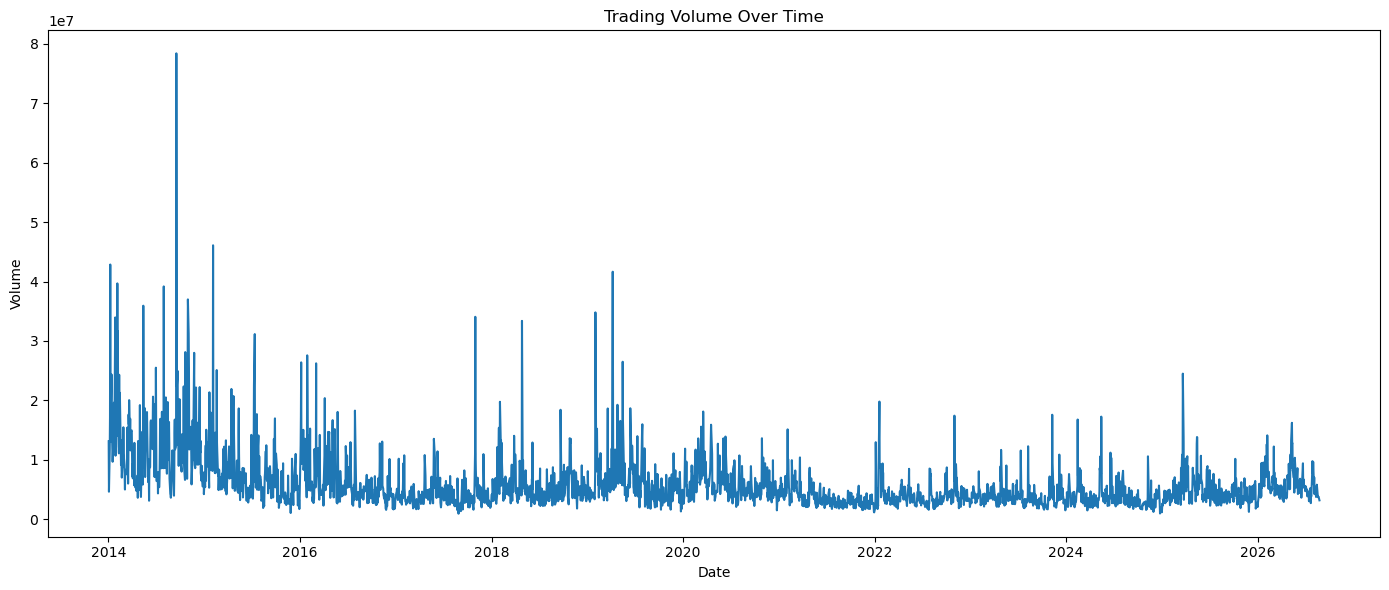

In [15]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Volume"
)

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

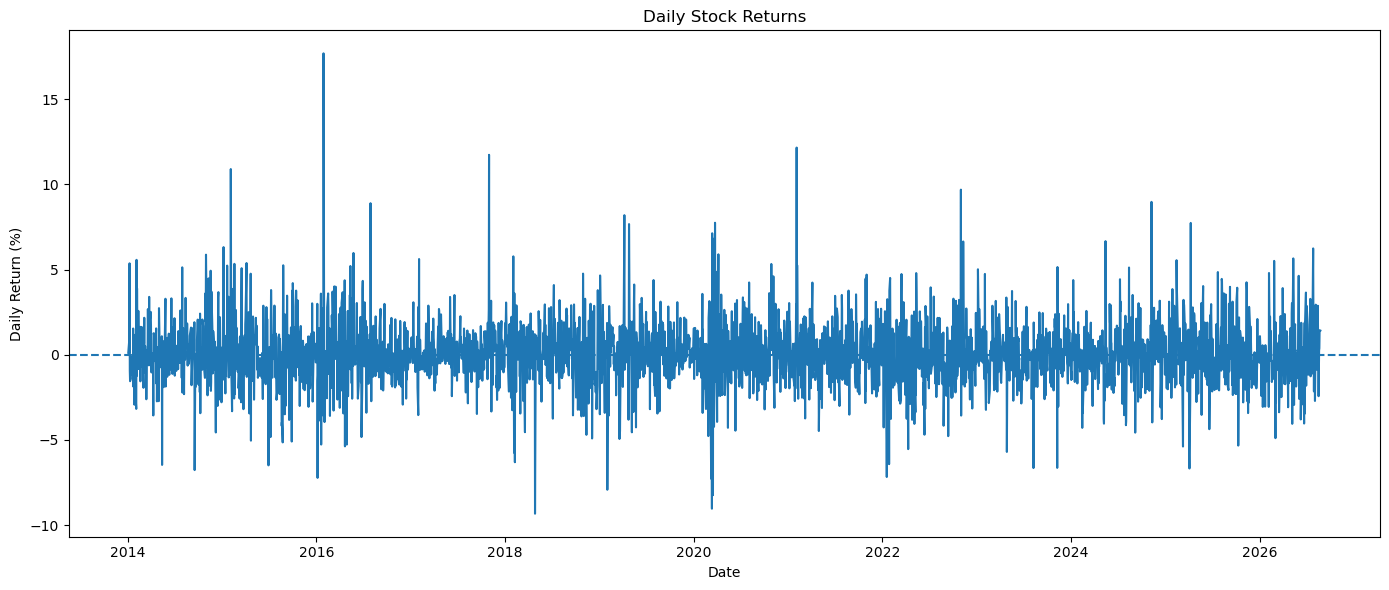

In [16]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Daily_Return"
)

plt.axhline(0, linestyle="--")

plt.title("Daily Stock Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.tight_layout()
plt.show()

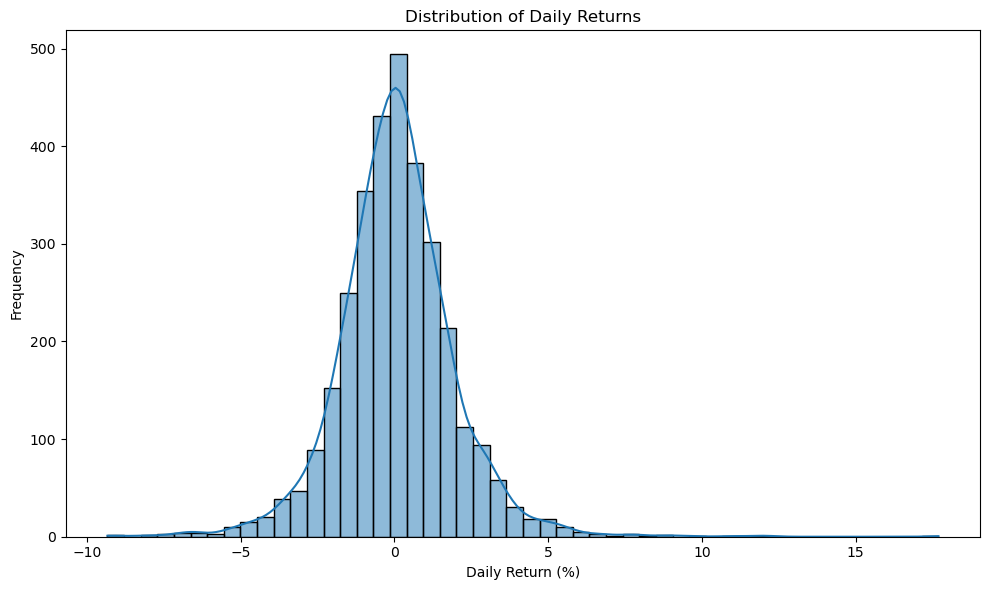

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [18]:
print(
    "Daily Return Volatility:",
    f"{df['Daily_Return'].std():.2f}%"
)

Daily Return Volatility: 1.89%


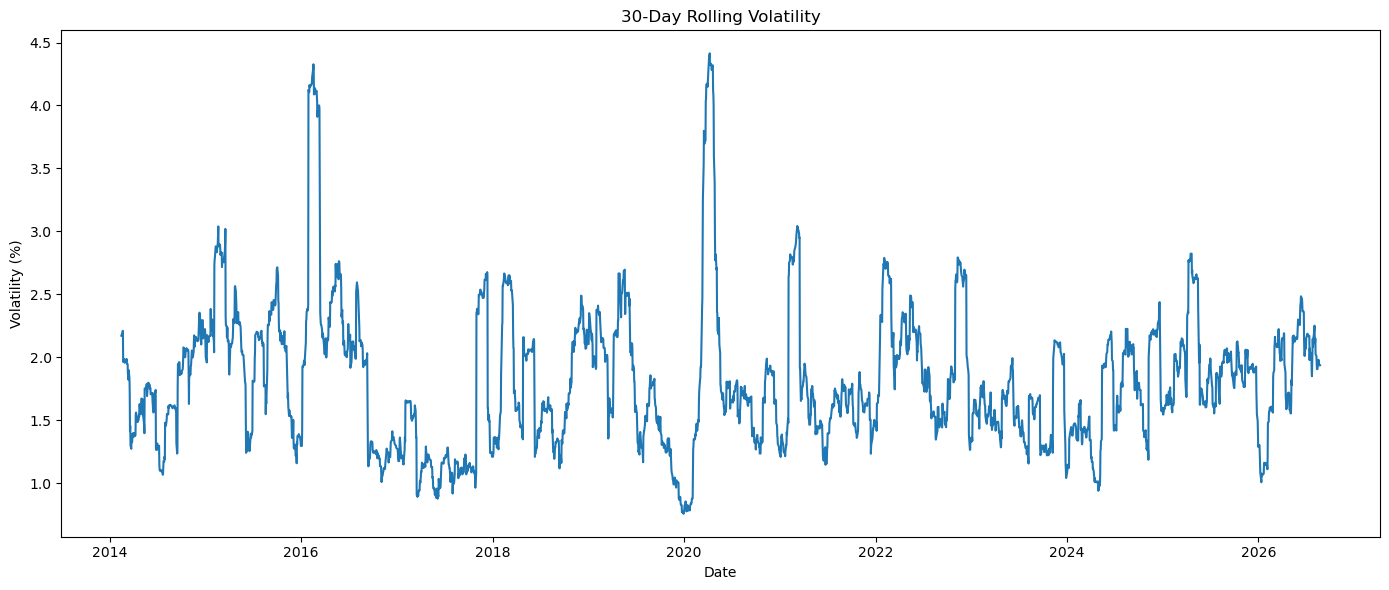

In [19]:
df["Rolling_30D_Volatility"] = (
    df["Daily_Return"]
    .rolling(30)
    .std()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Rolling_30D_Volatility"
)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.tight_layout()
plt.show()

In [20]:
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()
df["MA_200"] = df["Close"].rolling(200).mean()

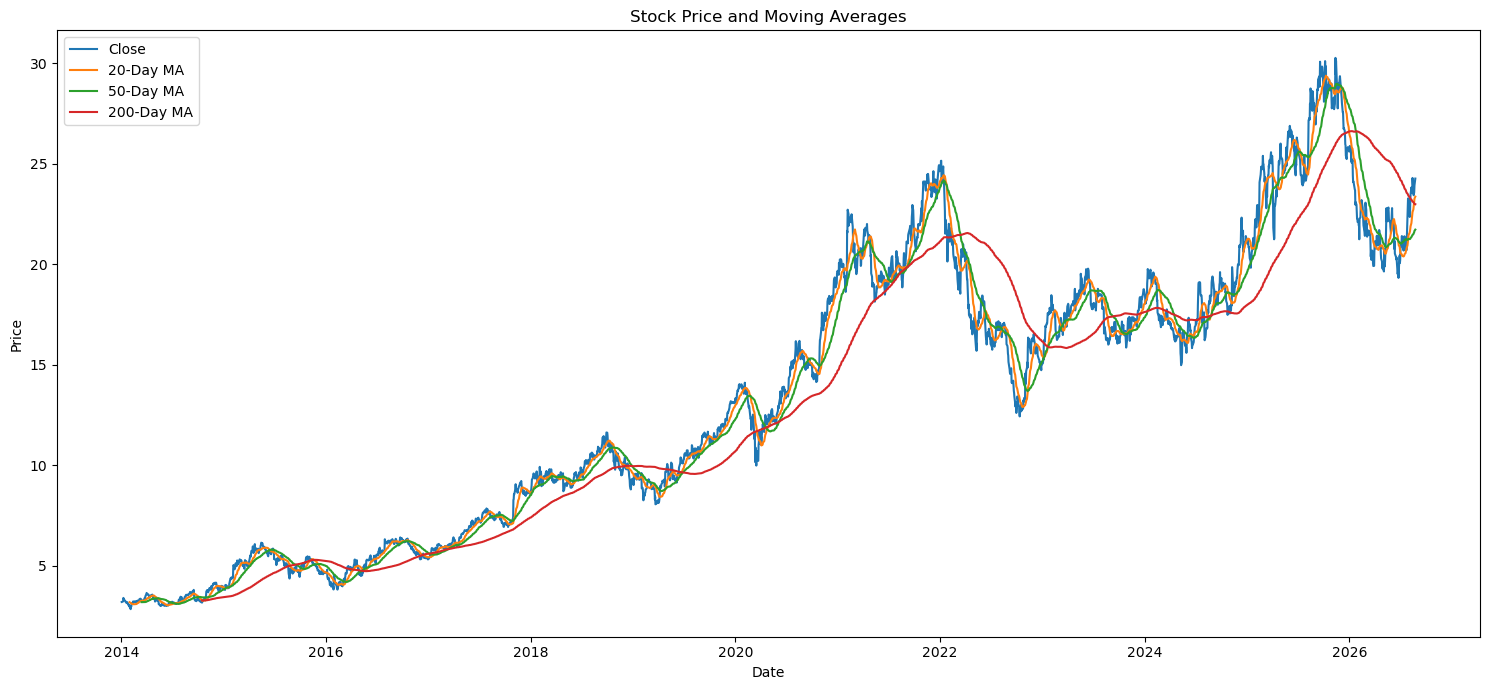

In [21]:
plt.figure(figsize=(15, 7))

plt.plot(
    df["Date"],
    df["Close"],
    label="Close"
)

plt.plot(
    df["Date"],
    df["MA_20"],
    label="20-Day MA"
)

plt.plot(
    df["Date"],
    df["MA_50"],
    label="50-Day MA"
)

plt.plot(
    df["Date"],
    df["MA_200"],
    label="200-Day MA"
)

plt.title("Stock Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
yearly = df.groupby("Year").agg(
    Average_Close=("Close", "mean"),
    Highest_Close=("Close", "max"),
    Lowest_Close=("Close", "min"),
    Average_Volume=("Volume", "mean"),
    Total_Volume=("Volume", "sum")
)

yearly

,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Total_Volume
Year,,,,,
2014,3.39,4.17,2.85,"12,945,730.16",3262324000
2015,5.13,6.15,3.81,"7,721,849.21",1945906000
2016,5.32,6.42,3.82,"6,566,956.35",1654873000
2017,7.08,9.22,5.37,"4,226,890.44",1060949500
2018,9.85,11.63,8.71,"5,648,434.26",1417757000
2019,10.36,13.19,8.06,"6,530,214.29",1645614000
2020,14.34,19.67,9.99,"6,156,049.41",1557480500
2021,21.02,24.93,18.14,"3,652,849.21",920518000
2022,17.23,25.15,12.43,"4,134,101.59",1037659500


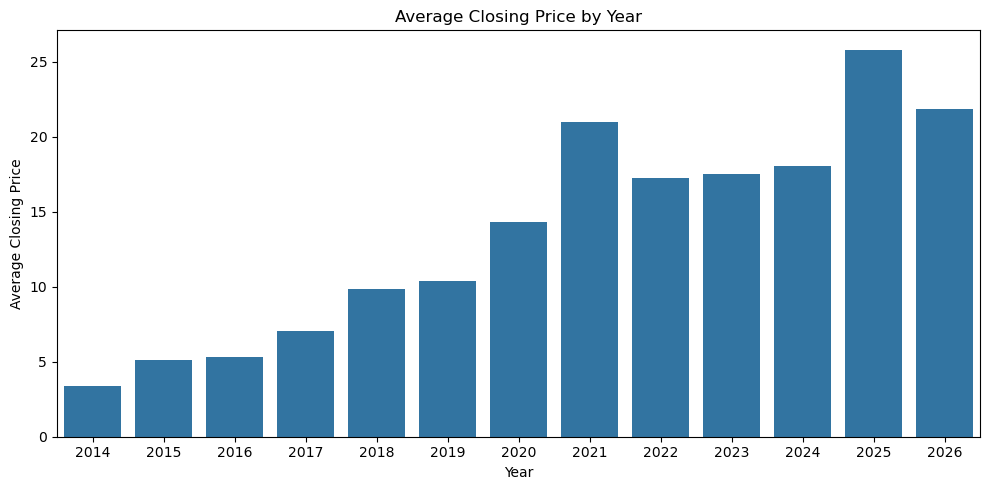

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=yearly.reset_index(),
    x="Year",
    y="Average_Close"
)

plt.title("Average Closing Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.tight_layout()
plt.show()

In [24]:
monthly = df.groupby("YearMonth").agg(
    Average_Close=("Close", "mean"),
    Highest_Close=("Close", "max"),
    Lowest_Close=("Close", "min"),
    Average_Volume=("Volume", "mean"),
    Average_Return=("Daily_Return", "mean")
)

monthly.head()

,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Average_Return
YearMonth,,,,,
2014-01,3.18,3.41,2.94,"16,504,452.38",-0.41
2014-02,3.16,3.28,2.85,"15,885,868.42",0.59
2014-03,3.32,3.59,3.20,"11,661,714.29",0.45
2014-04,3.50,3.65,3.32,"7,405,047.62",-0.37
2014-05,3.16,3.32,3.01,"12,719,000.00",-0.39


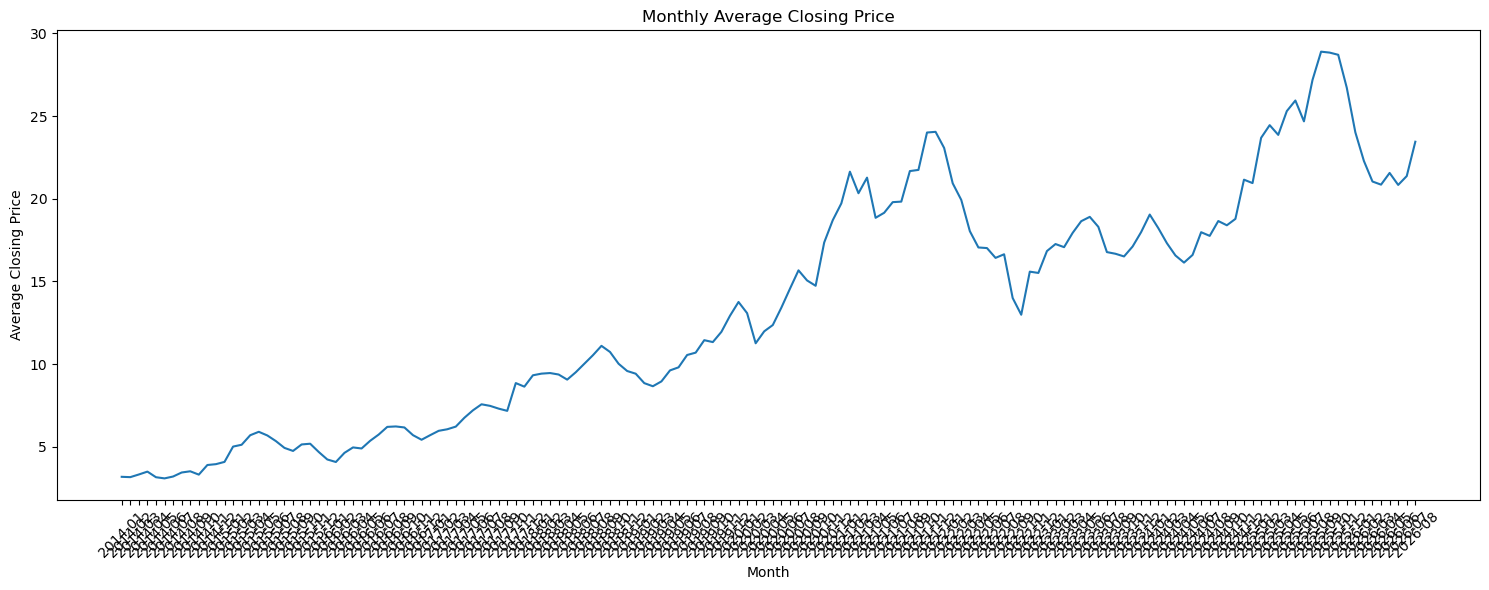

In [25]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly.reset_index(),
    x="YearMonth",
    y="Average_Close"
)

plt.title("Monthly Average Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
quarterly = df.groupby(
    ["Year", "Quarter"]
).agg(
    Average_Close=("Close", "mean"),
    Highest_Close=("Close", "max"),
    Lowest_Close=("Close", "min"),
    Average_Volume=("Volume", "mean"),
    Average_Return=("Daily_Return", "mean")
)

quarterly

Average_Close  Highest_Close  Lowest_Close  Average_Volume  \
Year Quarter                                                               
2014 1                 3.22           3.59          2.85   14,644,606.56   
     2                 3.25           3.65          3.01   10,749,079.37   
     3                 3.38           3.81          3.11   13,590,750.00   
     4                 3.70           4.17          3.17   12,843,796.88   
2015 1                 4.75           5.32          3.81   10,365,065.57   
     2                 5.76           6.15          5.12    7,970,809.52   
     3                 5.01           5.55          4.37    7,693,328.12   
     4                 5.00           5.46          4.58    4,985,984.38   
2016 1                 4.32           4.99          3.82    8,587,344.26   
     2                 5.08           5.55          4.51    7,884,007.81   
     3                 6.07           6.42          5.52    5,312,062.50   
     4                 5.76           6.36          5.32    4,547,563.49   
2017 1                 5.91           6.42          5.37    3,882,540.32   
     2                 6.75           7.40          5.96    4,777,547.62   
     3                 7.45           7.86          6.94    3,647,055.56   
     4                 8.20           9.22          6.93    4,594,952.38   
2018 1                 9.40           9.92          8.74    6,414,606.56   
     2                 9.31           9.90          8.71    5,582,281.25   
     3                10.54          11.63          9.39    4,712,690.48   
     4                10.15          11.62          8.80    5,909,531.75   
2019 1                 8.98           9.63          8.06    6,761,090.16   
     2                 9.46          10.39          8.12    9,149,611.11   
     3                10.88          11.67         10.34    5,760,835.94   
     4                12.05          13.19         10.98    4,501,070.31   
2020 1                12.66          14.11          9.99    7,186,919.35   
     2                12.60          13.91         11.03    6,925,428.57   
     3                15.09          16.19         13.42    5,196,687.50   
     4                16.92          19.67         14.14    5,359,398.44   
2021 1                20.55          22.71         18.62    5,312,418.03   
     2                19.77          22.00         18.14    3,643,785.71   
     3                20.43          22.95         18.85    2,906,304.69   
     4                23.28          24.93         20.64    2,826,539.06   
2022 1                21.25          25.15         18.54    4,679,645.16   
     2                17.36          20.59         15.70    3,903,233.87   
     3                15.71          17.17         12.61    3,435,523.44   
     4                14.70          16.52         12.43    4,534,087.30   
2023 1                17.06          18.46         15.08    3,921,645.16   
     2                18.52          19.78         17.41    3,954,669.35   
     3                17.23          18.78         16.00    3,748,547.62   
     4                17.18          18.76         15.86    3,930,373.02   
2024 1                18.21          19.76         16.87    4,146,467.21   
     2                16.43          17.34         14.98    4,313,936.51   
     3                18.11          19.61         16.22    3,752,132.81   
     4                19.42          22.32         17.48    2,978,384.38   
2025 1                23.04          25.57         19.82    4,954,305.00   
     2                25.02          26.88         21.24    5,968,298.39   
     3                26.89          30.07         23.92    4,068,553.12   
     4                28.07          30.26         25.23    4,013,843.75   
2026 1                22.41          25.88         19.91    6,261,183.61   
     2                21.08          22.82         19.32    6,446,380.65   
     3                22.25          24.29         20.21    4,

In [27]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

weekday = df.groupby("DayOfWeek").agg(
    Average_Close=("Close", "mean"),
    Average_Return=("Daily_Return", "mean"),
    Volatility=("Daily_Return", "std"),
    Average_Volume=("Volume", "mean")
).reindex(weekday_order)

weekday

,Average_Close,Average_Return,Volatility,Average_Volume
DayOfWeek,,,,
Monday,13.39,0.02,1.77,"5,659,167.28"
Tuesday,13.39,0.10,1.84,"5,836,753.89"
Wednesday,13.37,0.16,1.94,"5,973,040.64"
Thursday,13.31,-0.01,1.88,"5,976,723.59"
Friday,13.37,0.14,2.02,"5,770,077.99"


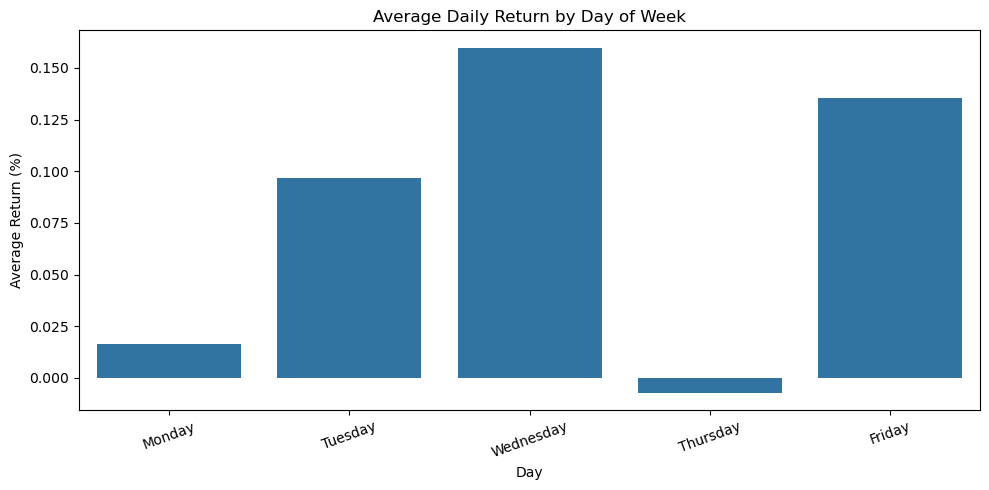

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday.reset_index(),
    x="DayOfWeek",
    y="Average_Return"
)

plt.title("Average Daily Return by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Return (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [29]:
best_days = df.nlargest(10, "Daily_Return")[
    ["Date", "Open", "High", "Low", "Close", "Volume", "Daily_Return"]
]

best_days

,Date,Open,High,Low,Close,Volume,Daily_Return
522,2016-01-29,4.26,4.62,4.24,4.50,27585000,17.69
1784,2021-02-03,21.07,21.85,20.81,21.66,15131000,12.16
965,2017-10-31,8.25,8.64,8.19,8.29,34069000,11.74
274,2015-02-04,4.68,4.99,4.62,4.88,46101000,10.90
2224,2022-11-01,13.89,14.64,13.89,14.57,17435500,9.69
2732,2024-11-08,19.45,20.61,19.45,19.85,10593700,8.98
648,2016-07-29,6.12,6.34,6.10,6.32,18282000,8.90
1324,2019-04-08,8.28,9.04,8.28,8.98,41655500,8.20
1566,2020-03-24,10.88,11.02,10.74,11.02,11409500,7.75
2834,2025-04-09,21.31,23.14,21.09,22.97,7765100,7.74


In [30]:
worst_days = df.nsmallest(10, "Daily_Return")[
    ["Date", "Open", "High", "Low", "Close", "Volume", "Daily_Return"]
]

worst_days

,Date,Open,High,Low,Close,Volume,Daily_Return
1087,2018-04-27,9.06,9.06,8.52,8.71,33381500,-9.33
1558,2020-03-12,10.54,10.72,9.95,10.16,10360500,-9.03
1560,2020-03-16,10.05,10.41,9.84,9.99,7294500,-8.24
1279,2019-02-01,9.59,9.60,8.66,8.85,34814000,-7.92
1555,2020-03-09,11.25,11.69,11.21,11.31,6874000,-7.27
506,2016-01-06,4.80,4.80,4.39,4.46,26404500,-7.22
2025,2022-01-18,23.65,23.80,22.53,22.65,15215500,-7.17
178,2014-09-17,3.49,3.61,3.48,3.55,78397000,-6.77
2831,2025-04-04,22.27,22.50,21.76,21.82,7990900,-6.67
2416,2023-08-09,17.83,17.83,16.33,16.56,12284000,-6.65


In [31]:
highest_volume_days = df.nlargest(10, "Volume")[
    ["Date", "Close", "Volume", "Daily_Return"]
]

highest_volume_days

,Date,Close,Volume,Daily_Return
178,2014-09-17,3.55,78397000,-6.77
179,2014-09-18,3.39,50137500,-4.45
274,2015-02-04,4.88,46101000,10.90
4,2014-01-08,3.41,42864500,5.37
1324,2019-04-08,8.98,41655500,8.20
22,2014-02-04,3.01,39691000,5.57
145,2014-07-31,3.46,39182500,5.13
210,2014-10-31,3.73,36996000,5.88
91,2014-05-14,3.10,35936000,-6.46
1279,2019-02-01,8.85,34814000,-7.92


In [32]:
numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "Daily_Range",
    "Open_Close_Difference"
]

correlation = df[numeric_columns].corr()

correlation

,Open,High,Low,Close,Volume,Daily_Return,Daily_Range,Open_Close_Difference
Open,1.00,1.00,1.00,1.00,-0.35,-0.01,0.64,-0.02
High,1.00,1.00,1.00,1.00,-0.35,-0.00,0.64,-0.01
Low,1.00,1.00,1.00,1.00,-0.36,-0.00,0.63,-0.01
Close,1.00,1.00,1.00,1.00,-0.35,0.00,0.64,-0.00
Volume,-0.35,-0.35,-0.36,-0.35,1.00,0.07,0.02,-0.00
Daily_Return,-0.01,-0.00,-0.00,0.00,0.07,1.00,0.00,0.50
Daily_Range,0.64,0.64,0.63,0.64,0.02,0.00,1.00,-0.09
Open_Close_Difference,-0.02,-0.01,-0.01,-0.00,-0.00,0.50,-0.09,1.00


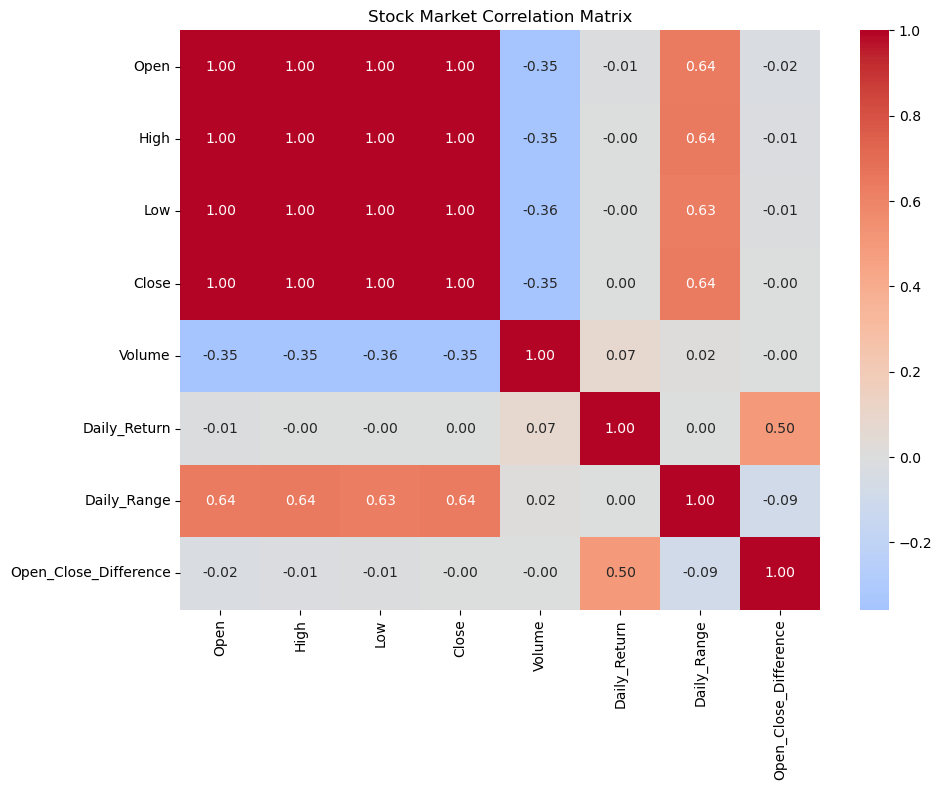

In [33]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Stock Market Correlation Matrix")
plt.tight_layout()
plt.show()

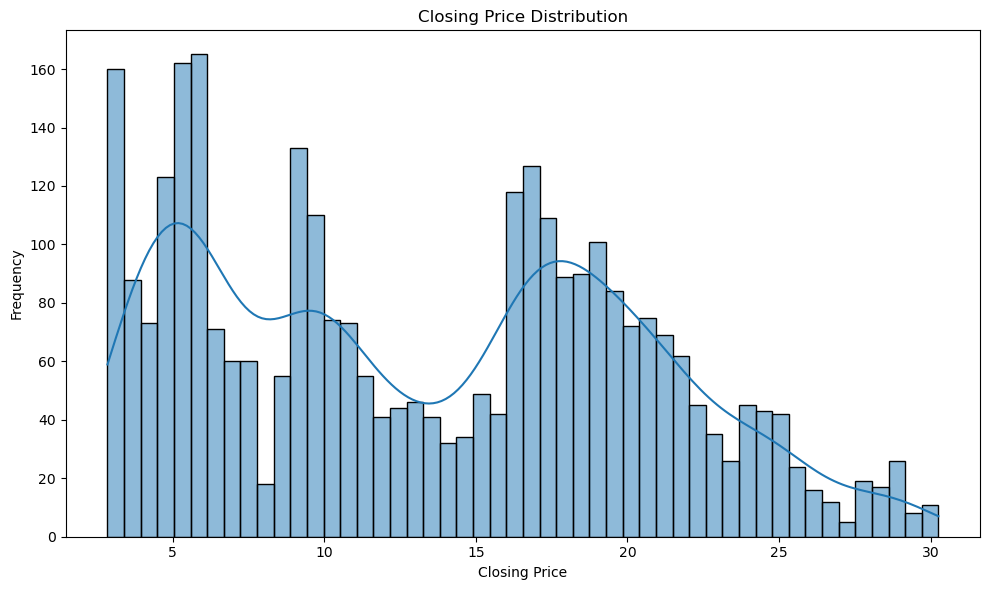

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Close"],
    bins=50,
    kde=True
)

plt.title("Closing Price Distribution")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

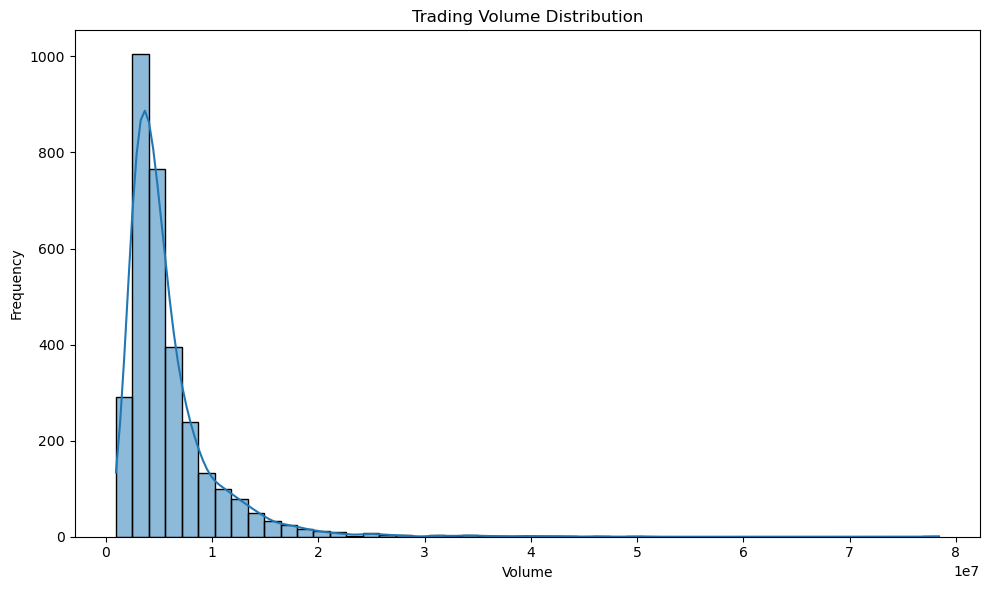

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Volume"],
    bins=50,
    kde=True
)

plt.title("Trading Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

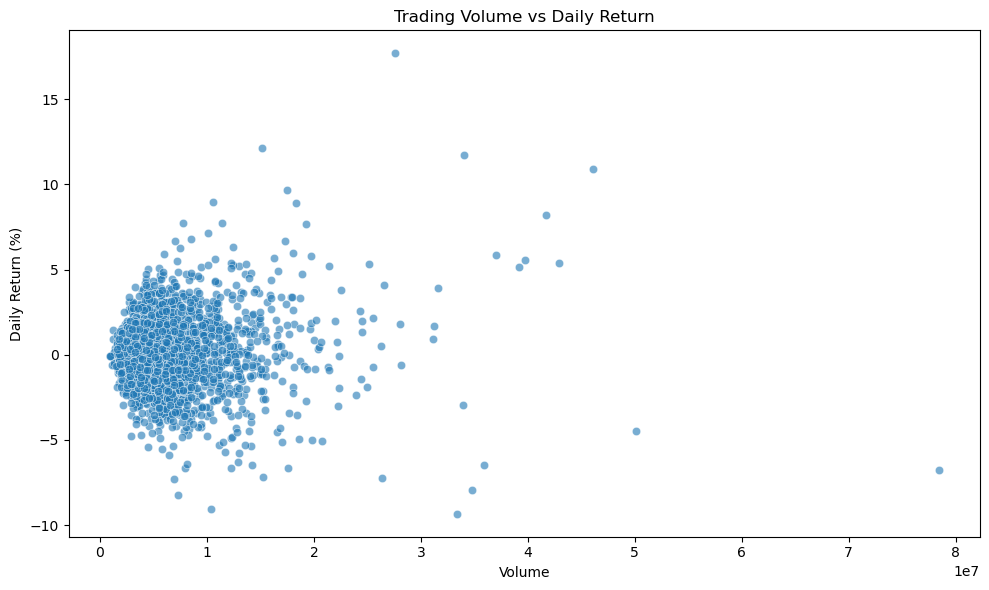

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(3000, len(df)), random_state=42),
    x="Volume",
    y="Daily_Return",
    alpha=0.6
)

plt.title("Trading Volume vs Daily Return")
plt.xlabel("Volume")
plt.ylabel("Daily Return (%)")
plt.tight_layout()
plt.show()

In [38]:
df["Cumulative_Max"] = df["Close"].cummax()

df["Drawdown"] = (
    (df["Close"] - df["Cumulative_Max"])
    / df["Cumulative_Max"]
) * 100

max_drawdown = df["Drawdown"].min()

print(
    f"Maximum Drawdown: {max_drawdown:.2f}%"
)

Maximum Drawdown: -50.56%


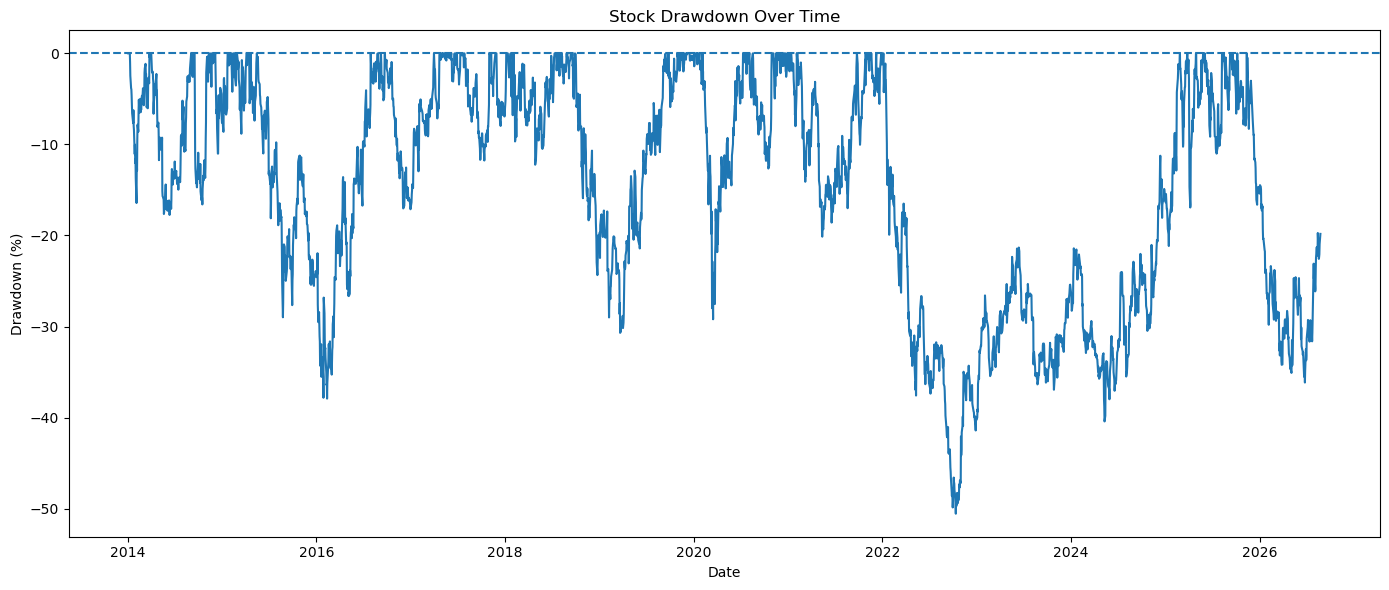

In [39]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Drawdown"
)

plt.axhline(0, linestyle="--")

plt.title("Stock Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.tight_layout()
plt.show()

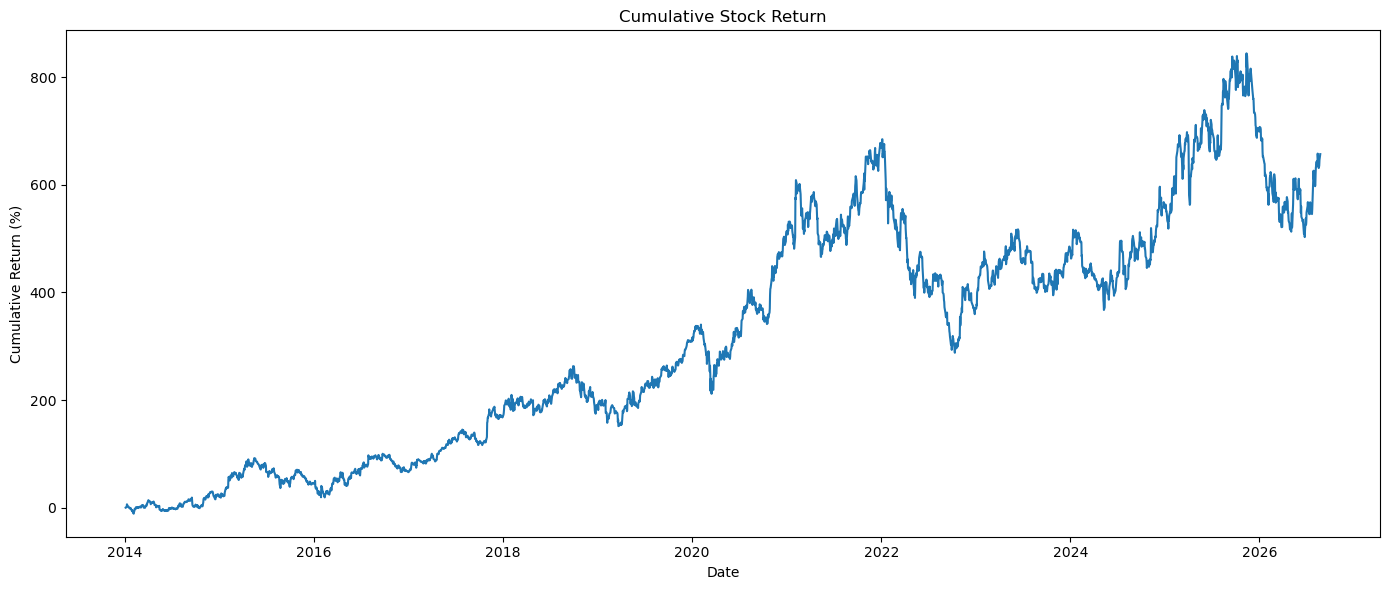

In [40]:
df["Cumulative_Return"] = (
    (1 + df["Daily_Return"] / 100)
    .cumprod() - 1
) * 100

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Cumulative_Return"
)

plt.title("Cumulative Stock Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.tight_layout()
plt.show()

In [41]:
positive_days = (df["Daily_Return"] > 0).sum()
negative_days = (df["Daily_Return"] < 0).sum()
unchanged_days = (df["Daily_Return"] == 0).sum()

direction_summary = pd.DataFrame({
    "Type": [
        "Positive",
        "Negative",
        "Unchanged"
    ],
    "Days": [
        positive_days,
        negative_days,
        unchanged_days
    ]
})

direction_summary

,Type,Days
0,Positive,1625
1,Negative,1534
2,Unchanged,19


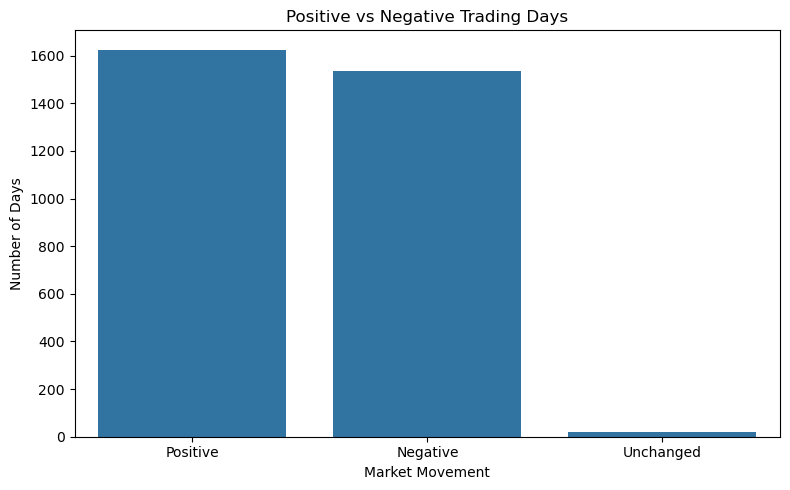

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=direction_summary,
    x="Type",
    y="Days"
)

plt.title("Positive vs Negative Trading Days")
plt.xlabel("Market Movement")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

In [45]:
summary = pd.DataFrame({
    "Metric": [
        "Trading Days",
        "Start Date",
        "End Date",
        "Highest Price",
        "Lowest Price",
        "Highest Closing Price",
        "Lowest Closing Price",
        "Average Closing Price",
        "Average Trading Volume",
        "Average Daily Return",
        "Daily Volatility",
        "Maximum Drawdown",
        "Positive Trading Days",
        "Negative Trading Days"
    ],
    "Value": [
        len(df),
        df["Date"].min().date(),
        df["Date"].max().date(),
        df["High"].max(),
        df["Low"].min(),
        df["Close"].max(),
        df["Close"].min(),
        df["Close"].mean(),
        df["Volume"].mean(),
        df["Daily_Return"].mean(),
        df["Daily_Return"].std(),
        max_drawdown,
        positive_days,
        negative_days
    ]
})

summary

,Metric,Value
0,Trading Days,3179
1,Start Date,2014-01-02
2,End Date,2026-08-24
3,Highest Price,30.34
4,Lowest Price,2.84
5,Highest Closing Price,30.26
6,Lowest Closing Price,2.85
7,Average Closing Price,13.37
8,Average Trading Volume,"5,846,251.24"
9,Average Daily Return,0.08


In [49]:
import os

os.makedirs("analysis_outputs", exist_ok=True)

df.to_csv(
    "analysis_outputs/cleaned_stock_data.csv",
    index=False
)

yearly.to_csv(
    "analysis_outputs/yearly_analysis.csv"
)

monthly.to_csv(
    "analysis_outputs/monthly_analysis.csv"
)

quarterly.to_csv(
    "analysis_outputs/quarterly_analysis.csv"
)

weekday.to_csv(
    "analysis_outputs/weekday_analysis.csv"
)

best_days.to_csv(
    "analysis_outputs/best_trading_days.csv",
    index=False
)

worst_days.to_csv(
    "analysis_outputs/worst_trading_days.csv",
    index=False
)

highest_volume_days.to_csv(
    "analysis_outputs/highest_volume_days.csv",
    index=False
)

summary.to_csv(
    "analysis_outputs/stock_market_kpis.csv",
    index=False
)